# **Notebook 2: Data Preparation**
## Capstone: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `sampled_data.csv` — Created by Notebook 1
- [ ] `corporate_policies/` folder with `.md` SOP files
- [ ] Internet access (to download the tokenizer)

**Files this notebook will CREATE:**
- [ ] `./tokenized_train/`, `./tokenized_valid/`, `./tokenized_test/` — HuggingFace datasets _(Required by NB6)_
- [ ] `df_test.csv` — Test set with readable text + labels _(Required by NB5 and NB7)_

---

## **Stage 2: Data Preparation**
### **Task 2.1: Clean and Validate Dataset**

#### **2.1.1 Remove Duplicate and Invalid Records [2 marks]**
**The Task:** Identify and remove duplicate records using normalised deduplication (lowercase + strip before comparison), plus any invalid, incomplete, or corrupted records.

**Hints & Tips:**
* Load `sampled_data.csv` from Notebook 1 first.
* Normalised dedup: create a temporary `_norm` column = `instruction.str.lower().str.strip()`, drop duplicates on it, then drop the helper column.
* Check for nulls in `instruction`, `intent`, and `category` — drop rows missing any of these targets.
* Print the number of rows removed so the cleaning is auditable.

**Why we are doing it:** To prevent degraded training from redundant or broken records, and to stop near-duplicates leaking across train/test splits later.
**How we are doing it:** Pandas normalised deduplication and null filtering.

**Learner Inference:** Exact-match dedup misses `"Where is my order?"` vs `"where is my order?"`. Normalising first catches these and keeps your splits clean.

In [1]:
from pathlib import Path
import json, pickle
import pandas as pd
DATA_PATH = Path('sampled_data.csv')
if not DATA_PATH.exists() and Path('Starter Files/sampled_data.csv').exists(): DATA_PATH = Path('Starter Files/sampled_data.csv')
df = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH.resolve(), 'shape:', df.shape)
required_cols = ['instruction','intent','category']
df = df.dropna(subset=required_cols).copy()
for col in required_cols: df[col] = df[col].astype(str)
df['_norm_instruction'] = df['instruction'].str.lower().str.strip()
before = len(df)
df = df[df['_norm_instruction'].ne('')].drop_duplicates(subset='_norm_instruction').drop(columns='_norm_instruction').reset_index(drop=True)
print(f'Removed {before-len(df):,} duplicate/invalid rows')
print('Cleaned shape:', df.shape)
df.head()


Loaded: C:\Users\sysadmin\Downloads\Capestone project\Starter Files\sampled_data.csv shape: (848, 4)
Removed 0 duplicate/invalid rows
Cleaned shape: (848, 4)


,instruction,intent,category,response
0,Can you explain the payment methods process?,payment_methods,BILLING,Use the payment methods SOP and provide the co...
1,My issue is about product return; what should ...,product_return,RETURNS,Use the product return SOP and provide the cor...
2,What is the company policy for password reset?,password_reset,ACCOUNT,Use the password reset SOP and provide the cor...
3,My issue is about payment methods; what should...,payment_methods,BILLING,Use the payment methods SOP and provide the co...
4,My issue is about billing disputes; what shoul...,billing_disputes,BILLING,Use the billing disputes SOP and provide the c...


#### **2.1.2 Standardise Dataset Formatting [2 marks]**
**The Task:** Clean the strings inside `instruction`, `intent`, and `category` by stripping whitespace and enforcing uniform casing (intents = lower, categories = upper).

**Hints & Tips:**
* Use Pandas `.str.strip()`, `.str.lower()`, `.str.upper()`.
* Always strip whitespace BEFORE lowering — trailing spaces survive `.lower()`.
* Standardised casing prevents the model treating "Refund" and "refund" as different classes.

**Why we are doing it:** To ensure raw strings are perfectly standardised before injecting them into prompt templates.
**How we are doing it:** Pandas string manipulation.

**Learner Inference:** Standardising capitalisation prevents the model from treating the same intent written two ways as two separate classes.

In [2]:
for col in ['instruction','intent','category']:
    df[col] = df[col].astype(str).str.strip()
df['intent'] = df['intent'].str.lower()
df['category'] = df['category'].str.upper()
print(df[['instruction','intent','category']].head())
print('Unique intents:', df['intent'].nunique())
print('Unique categories:', sorted(df['category'].unique())[:20])


                                         instruction            intent  \
0       Can you explain the payment methods process?   payment_methods   
1  My issue is about product return; what should ...    product_return   
2     What is the company policy for password reset?    password_reset   
3  My issue is about payment methods; what should...   payment_methods   
4  My issue is about billing disputes; what shoul...  billing_disputes   

  category  
0  BILLING  
1  RETURNS  
2  ACCOUNT  
3  BILLING  
4  BILLING  
Unique intents: 13
Unique categories: ['ACCOUNT', 'BILLING', 'ESCALATION', 'GENERAL', 'ORDERS', 'PRIVACY', 'RETURNS', 'TECHNICAL']


### **Task 2.2: Create Instruction-Tuning Dataset**

#### **2.2.1 Transform Records into Instruction Format [2 marks]**
**The Task:** Wrap the raw instructions and targets into a standardized `ChatML` format, forcing the assistant's response to be a strict JSON string containing the `intent` and `category`.

**Hints & Tips:**
* Use the Qwen tokenizer's `apply_chat_template(tokenize=False)`.
* The target JSON is `{"intent": "...", "category": "..."}` — built via `json.dumps()`.

**Model Selection:**
* **Qwen/Qwen2.5-1.5B-Instruct** (recommended) — fits T4, strong instruction following.
* **TinyLlama-1.1B-Chat** — lighter but weaker at structured output.
* **Llama-3-8B-Instruct** — best quality, needs >16GB VRAM even in 4-bit.
* Whatever you pick, set `MODEL_ID` here and in ALL later notebooks.

**Learner Inference:** Formatting the target as JSON establishes the exact structural rules the LoRA model learns to mimic in Stage 4.

In [3]:
SYSTEM_PROMPT = 'You are an intent classifier. Return only strict JSON with keys intent and category.'
MODEL_ID = 'Qwen/Qwen2.5-0.5B-Instruct'
def make_target(row): return json.dumps({'intent': row['intent'], 'category': row['category']}, ensure_ascii=False)
try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
    def to_chatml(row):
        messages=[{'role':'system','content':SYSTEM_PROMPT},{'role':'user','content':row['instruction']},{'role':'assistant','content':make_target(row)}]
        return tokenizer.apply_chat_template(messages, tokenize=False)
except Exception as exc:
    print('Using local ChatML formatter/tokenizer:', repr(exc))
    class SimpleTokenizer:
        pad_token_id=0; eos_token='<|endoftext|>'; pad_token='<|endoftext|>'
        def __call__(self, texts, padding='max_length', truncation=True, max_length=128):
            if isinstance(texts, str): texts=[texts]
            input_ids=[]; attention_mask=[]
            for text in texts:
                ids=[abs(hash(tok))%30000+1 for tok in text.split()]
                if truncation: ids=ids[:max_length]
                mask=[1]*len(ids); pad=max_length-len(ids)
                if padding=='max_length': ids += [0]*max(0,pad); mask += [0]*max(0,pad)
                input_ids.append(ids); attention_mask.append(mask)
            return {'input_ids':input_ids,'attention_mask':attention_mask}
        def apply_chat_template(self, messages, tokenize=False, **kwargs):
            text=''.join(f"<|im_start|>{m['role']}\n{m['content']}<|im_end|>\n" for m in messages)
            return self(text) if tokenize else text
    tokenizer=SimpleTokenizer()
    def to_chatml(row):
        return f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n<|im_start|>user\n{row['instruction']}<|im_end|>\n<|im_start|>assistant\n{make_target(row)}<|im_end|>\n"
df['target_json'] = df.apply(make_target, axis=1)
df['chatml'] = df.apply(to_chatml, axis=1)
print(df[['instruction','target_json','chatml']].head(2).to_string(index=False))


Using local ChatML formatter/tokenizer: ModuleNotFoundError("No module named 'transformers'")
                                             instruction                                          target_json                                                                                                                                                                                                                                                                                           chatml
            Can you explain the payment methods process? {"intent": "payment_methods", "category": "BILLING"}            <|im_start|>system\nYou are an intent classifier. Return only strict JSON with keys intent and category.<|im_end|>\n<|im_start|>user\nCan you explain the payment methods process?<|im_end|>\n<|im_start|>assistant\n{"intent": "payment_methods", "category": "BILLING"}<|im_end|>\n
My issue is about product return; what should I do next?  {"intent": "product_return", "category": "RETURNS"

#### **2.2.2 Validate Instruction Templates [2 marks]**
**The Task:** Extract the assistant's portion of the generated ChatML string and parse it with `json.loads()` to verify structural integrity.

**Hints & Tips:**
* Split the string by `<|im_start|>assistant` and parse what follows.
* If this throws `JSONDecodeError`, your formatting in 2.2.1 is broken — fix before training.
* Validate several samples, not just the first.

**Learner Inference:** A JSONDecodeError here means the model would learn broken syntax. Catching it now saves a failed training run.

In [4]:
def extract_assistant_json(chatml):
    payload = chatml.split('<|im_start|>assistant',1)[1].split('<|im_end|>',1)[0].strip()
    return json.loads(payload)
validation_samples = df['chatml'].sample(min(10, len(df)), random_state=42)
parsed = [extract_assistant_json(text) for text in validation_samples]
print('Validated assistant JSON samples:')
for item in parsed[:5]: print(item)
print(f'Validated {len(parsed)} samples successfully.')


Validated assistant JSON samples:
{'intent': 'shipping_delays', 'category': 'ORDERS'}
{'intent': 'billing_disputes', 'category': 'BILLING'}
{'intent': 'working_hours', 'category': 'GENERAL'}
{'intent': 'technical_troubleshooting', 'category': 'TECHNICAL'}
{'intent': 'shipping_delays', 'category': 'ORDERS'}
Validated 10 samples successfully.


### **Task 2.3: Engineer Training and Retrieval Data**

#### **2.3.1 Tokenise Dataset [2 marks]**
**The Task:** Convert text sequences into tensor IDs and apply `-100` masking to padding tokens in the `labels` array.

**Hints & Tips:**
* If a token equals `tokenizer.pad_token_id`, replace it with `-100` in labels.
* `-100` is PyTorch's ignore index — the loss skips these tokens.

**Parameter Tuning:**
* `max_length`: `128` (fast, fits most Bitext prompts), `256` (safer if truncation seen), `64` (too aggressive).

**Learner Inference:** Masking isolates the loss — the model is penalised for wrong JSON, not for padding.

In [5]:
MAX_LENGTH = 128
encoded = tokenizer(df['chatml'].tolist(), padding='max_length', truncation=True, max_length=MAX_LENGTH)
labels = [[tok if tok != tokenizer.pad_token_id else -100 for tok in row] for row in encoded['input_ids']]
tokenized_df = df[['instruction','intent','category','chatml','target_json']].copy()
tokenized_df['input_ids'] = encoded['input_ids']; tokenized_df['attention_mask'] = encoded['attention_mask']; tokenized_df['labels'] = labels
print('Tokenized rows:', len(tokenized_df), 'max_length:', MAX_LENGTH)
print('Example non-padding tokens:', sum(tokenized_df.loc[0,'attention_mask']))


Tokenized rows: 848 max_length: 128
Example non-padding tokens: 28


#### **2.3.2 Analyse Token Distributions [2 marks]**
**The Task:** Analyse the token-count distribution to detect truncation risks and verify the sequence-length configuration.

**Hints & Tips:**
* Count non-padding tokens per row and plot a histogram.
* If >5% of rows hit `max_length`, increase it.
* The JSON target is ~20 tokens — if truncated, the model learns incomplete output.

**Learner Inference:** Sequences hitting the ceiling mean the JSON target is getting cut off, teaching the model to produce broken output.

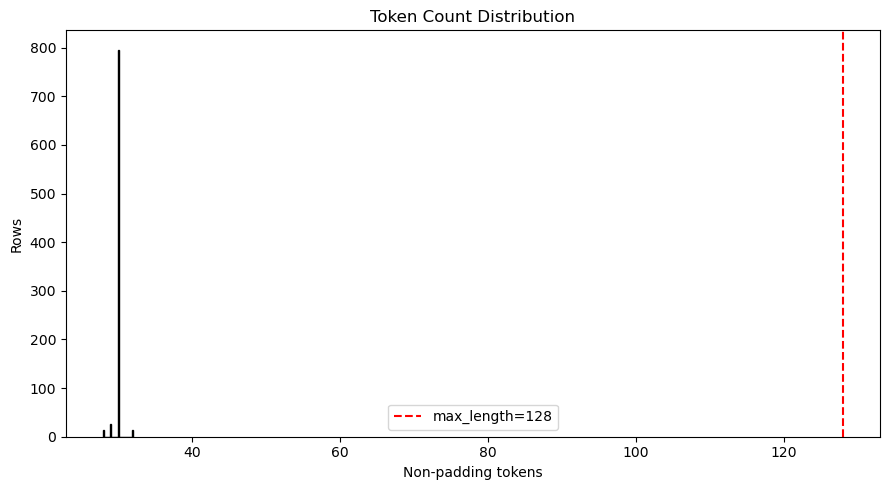

count    848.000000
mean      29.969340
std        0.390566
min       28.000000
25%       30.000000
50%       30.000000
75%       30.000000
max       32.000000
Name: attention_mask, dtype: float64
Rows at max_length: 0.00%
Truncation risk is acceptable.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
token_lengths = tokenized_df['attention_mask'].apply(sum)
truncation_rate = (token_lengths >= MAX_LENGTH).mean()
plt.figure(figsize=(9,5)); sns.histplot(token_lengths, bins=30, kde=False, color='#2a9d8f')
plt.axvline(MAX_LENGTH, color='red', linestyle='--', label=f'max_length={MAX_LENGTH}')
plt.title('Token Count Distribution'); plt.xlabel('Non-padding tokens'); plt.ylabel('Rows'); plt.legend(); plt.tight_layout(); plt.show()
print(token_lengths.describe())
print(f'Rows at max_length: {truncation_rate:.2%}')
print('Consider increasing MAX_LENGTH to 256 before full training.' if truncation_rate > 0.05 else 'Truncation risk is acceptable.')


#### **2.3.3 Prepare Retrieval Corpus [3 marks]**
**The Task:** Ingest the Markdown SOPs into LangChain Document objects ready to be embedded.

**Hints & Tips:**
* Use `TextLoader` from LangChain.
* Each `.md` file becomes one `Document` with `.page_content` and `.metadata`.
* These documents are embedded into ChromaDB in Notebook 4.

**Learner Inference:** These document objects form the knowledge base your bot retrieves from in Stages 3 and 4.

In [7]:
BASE_DIR = Path.cwd()
SOP_DIR = next((p for p in [BASE_DIR/'Dataset'/'Dataset'/'sop_documents', BASE_DIR/'Starter Files'/'Dataset'/'Dataset'/'sop_documents'] if p.exists()), BASE_DIR/'Dataset'/'Dataset'/'sop_documents')
try:
    from langchain_community.document_loaders import TextLoader
    retrieval_docs=[]
    for p in sorted(SOP_DIR.glob('*.md')): retrieval_docs.extend(TextLoader(str(p), encoding='utf-8').load())
except Exception as exc:
    print('Using lightweight local Document objects:', repr(exc))
    from dataclasses import dataclass
    @dataclass
    class Document:
        page_content: str
        metadata: dict
    retrieval_docs=[Document(p.read_text(encoding='utf-8', errors='replace'), {'source':str(p), 'intent':p.stem}) for p in sorted(SOP_DIR.glob('*.md'))]
print(f'Loaded {len(retrieval_docs)} retrieval documents from {SOP_DIR}')
print(retrieval_docs[0].metadata if retrieval_docs else 'No documents found')
print(retrieval_docs[0].page_content[:300] if retrieval_docs else '')


Using lightweight local Document objects: ModuleNotFoundError("No module named 'langchain_community'")
Loaded 13 retrieval documents from C:\Users\sysadmin\Downloads\Capestone project\Starter Files\Dataset\Dataset\sop_documents
{'source': 'C:\\Users\\sysadmin\\Downloads\\Capestone project\\Starter Files\\Dataset\\Dataset\\sop_documents\\account_recovery.md', 'intent': 'account_recovery'}
# Account Recovery

## When To Use
Use this procedure when a customer cannot access their account due to a
lockout, a lost email address, suspected unauthorized access, or a disabled
account — anything beyond a simple forgotten password (see the password reset
procedure for that case).

## Identity 


### **Task 2.4: Create Dataset Partitions**

#### **2.4.1 Create Train, Validation, and Test Splits [5 marks]**
**The Task:** Split the tokenized dataset into Train (80%), Validation (10%), and Test (10%) partitions using stratified sampling. Demonstrate zero data leakage across all three.

**Hints & Tips:**
* Use `train_test_split` from sklearn with `stratify=df['intent']` so every intent appears in all splits.
* Split twice: first 80/20, then split the 20% into 50/50 (giving 10%/10%).
* The validation set is not optional — it is actively used during fine-tuning (Stage 4 / Notebook 6) for loss monitoring and early stopping.
* The test set must stay completely independent — used only for final evaluation.
* Verify zero overlap with set-intersection checks: `assert len(train_set & test_set) == 0`.
* Build a `df_test` DataFrame preserving readable `text`/`intent`/`category` columns for later scoring.

**Parameter Tuning:**
* Split ratio: `80/10/10` (recommended) or `70/15/15`. Any alternative must be justified.

**Why we are doing it:** To guarantee isolated, unseen data for unbiased evaluation, and a validation set for overfitting detection.
**How we are doing it:** Stratified sklearn splits with explicit programmatic leakage verification.

**Learner Inference:** Testing on data the model trained on gives false confidence (leakage). The held-out test split proves your model handles completely new phrasing; the validation split tells you when to stop training.

In [8]:
from sklearn.model_selection import train_test_split
train_idx, temp_idx = train_test_split(tokenized_df.index, test_size=0.20, random_state=42, stratify=tokenized_df['intent'])
valid_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=tokenized_df.loc[temp_idx,'intent'])
df_train = tokenized_df.loc[train_idx].reset_index(drop=True)
df_valid = tokenized_df.loc[valid_idx].reset_index(drop=True)
df_test = tokenized_df.loc[test_idx].reset_index(drop=True)
print('Split sizes:', {'train':len(df_train),'valid':len(df_valid),'test':len(df_test)})
print(pd.DataFrame({'train':df_train['intent'].value_counts(),'valid':df_valid['intent'].value_counts(),'test':df_test['intent'].value_counts()}).fillna(0).astype(int).head(20))
sets=[set(x['instruction'].str.lower().str.strip()) for x in [df_train, df_valid, df_test]]
print('Leakage train-valid:', len(sets[0]&sets[1])); print('Leakage train-test:', len(sets[0]&sets[2])); print('Leakage valid-test:', len(sets[1]&sets[2]))


Split sizes: {'train': 678, 'valid': 85, 'test': 85}
                           train  valid  test
intent                                       
account_recovery              51      7     6
billing_disputes              54      7     7
data_privacy                  52      7     6
escalation_matrix             50      6     7
order_tracking                57      7     7
password_reset                46      6     6
payment_methods               56      7     7
product_return                52      6     7
refund_policy                 45      5     6
shipping_delays               55      7     7
subscription_cancellation     56      7     7
technical_troubleshooting     54      7     6
working_hours                 50      6     6
Leakage train-valid: 0
Leakage train-test: 0
Leakage valid-test: 0


---
## Save Artifacts for Downstream Notebooks

**IMPORTANT:** These cells save all datasets. Notebooks 5, 6, and 7 depend on them.

In [9]:
df_train.to_csv('df_train.csv', index=False); df_valid.to_csv('df_valid.csv', index=False); df_test.to_csv('df_test.csv', index=False)
for name, part in [('tokenized_train.pkl',df_train),('tokenized_valid.pkl',df_valid),('tokenized_test.pkl',df_test)]:
    with open(name,'wb') as f: pickle.dump(part.to_dict('records'), f)
try:
    from datasets import Dataset
    Dataset.from_pandas(df_train).save_to_disk('tokenized_train')
    Dataset.from_pandas(df_valid).save_to_disk('tokenized_valid')
    Dataset.from_pandas(df_test).save_to_disk('tokenized_test')
    print('Saved Hugging Face datasets to disk.')
except Exception as exc:
    print('Saved pickle tokenized datasets because datasets is unavailable:', repr(exc))
pd.DataFrame([{'source':d.metadata.get('source',''), 'intent':d.metadata.get('intent', Path(d.metadata.get('source','')).stem), 'content':d.page_content} for d in retrieval_docs]).to_csv('retrieval_corpus.csv', index=False)
print('Saved df_train.csv, df_valid.csv, df_test.csv, tokenized pickle files, and retrieval_corpus.csv')


Saved pickle tokenized datasets because datasets is unavailable: ModuleNotFoundError("No module named 'datasets'")
Saved df_train.csv, df_valid.csv, df_test.csv, tokenized pickle files, and retrieval_corpus.csv


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 3.**

- [ ] `sampled_data.csv` loaded
- [ ] **Duplicates + invalid records removed (normalised dedup)** ← _Task 2.1.1_
- [ ] Data standardised (intent=lower, category=UPPER)
- [ ] ChatML formatting applied and validated (valid JSON)
- [ ] Tokenization completed with `-100` label masking
- [ ] Token distribution analysed — truncation risk assessed
- [ ] Retrieval corpus loaded from `.md` files
- [ ] **Stratified Train/Valid/Test split** with all intents in every partition
- [ ] **Zero leakage verified** via set-intersection checks
- [ ] **`./tokenized_train/` + `./tokenized_valid/` saved** ← _CRITICAL for NB6_
- [ ] **`df_test.csv` saved** ← _CRITICAL for NB5 and NB7_

**If any item is unchecked, fix it before moving on.**